# ***VLLM Setup***

In [ ]:
# python -m vllm.entrypoints.openai.api_server --model=/workspace/models/llama8B --host=127.0.0.1 --port=8000 --max_model_len=10000
# --quantization=bitsandbytes

# ***Libraries***

### ***Install***

In [ ]:
!pip install faiss-gpu
!pip install -U sentence-transformers
!pip install openai
%pip install -q -U google-generativeai
!pip install -q pandas
!pip install -q scikit-learn
!pip install -q matplotlib
!pip install -q seaborn
!pip install openpyxl
!pip install sentencepiece
!pip install protobuf

### ***Imports***

In [ ]:
from huggingface_hub import login

login(token="Your HuggingFace Token")

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix , f1_score, accuracy_score,precision_recall_fscore_support , precision_score , recall_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import regex as re
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
import time
from sentence_transformers import SentenceTransformer
import warnings
from huggingface_hub import login
from  tqdm import tqdm_notebook, tqdm
import csv
import os
from openai import OpenAI
import openai

import google.generativeai as genai

warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
tqdm.pandas()

# ***Constants***

### ***Keys***

In [ ]:
openai.api_key =  'Your OpenAI key'
# If using Openrouter, set the following variables
openrouter_base_url = 'https://openrouter.ai/api/v1'
openrouter_key = 'Your openRouter Key'

huggingface_key = ''

vllm_api_key = "EMPTY"
vllm_base_url = "http://127.0.0.1:8000/v1"

### ***Variables and Paths***

In [ ]:
root_dir = 'path to your root directory'
data_dir = os.path.join(root_dir, 'data')
train_orig_data_path = os.path.join(data_dir, 'train.csv')
valid_orig_data_path = os.path.join(data_dir, 'validation.csv')
test_orig_data_path = os.path.join(data_dir, 'Test_DePiC.xlsx')

train_embed_data_path = os.path.join(data_dir, 'train_with_embed.pkl')
valid_embed_data_path = os.path.join(data_dir, 'validation_with_embed.pkl')
test_embed_data_path = os.path.join(data_dir, 'test_with_embed.pkl')

map_label = {0: 'healthy', 1: 'AD'}
CLASS_To_LABEL = {1 : "AD" , 0 : "Healthy"}

### ***Prompts***

In [ ]:
instruct_prompts = {}
reasoning_prompts = {}

instruct_prompts['prompt_v1']= (
    'You are an expert in cognitive health and language analysis. You will analyze a spoken language transcript from a person describing the "cookie theft" picture. This is not written text but a transcription of spontaneous speech.'
    '\nAnalyze the provided transcript and classify it into one of two categories: "Healthy" for a healthy cognitive state or "AD" for Alzheimer disease.'
    '\nProvide only the label ("Healthy" or "AD") as the output. Do not include explanations or additional text.'
    'The output should be in JSON format, like {"label": "predicted label"}'
)

instruct_prompts['prompt_v2_reason'] = ('You are the Alzheimer’s Detection Assistant. Your task is to analyze the linguistic features of the provided transcripts of spoken text for potential indicators of Alzheimer’s disease.'
                                        '\nFor each instance, label it as either "healthy" or "AD" based on your analysis of the cognitive patterns in the speech and bring a **short reasons** first why you classified as healthy or Alzheimer Disease.'
                                        '\nStart by briefly explaining your reasoning , then output your final decision in the following JSON format:'
                                        '\n{"reason" : "provided  reason" ,"label": "predicted label"}')


instruct_prompts['tot_3exp_1'] = ('\nSimulate three brilliant, logical experts collaboratively a trascript text. Each one verbosely explains their thought process in real-time, considering the prior explanations of others and openly acknowledging mistakes. At each step, whenever possible, each expert refines and builds upon the thoughts of others, acknowledging their contributions. They continue until there is a definitive answer to the question. For clarity, your entire response should be in a markdown table.'
                                  '\nEach expert\'s task is to analyze the linguistic features of the provided transcripts of spoken text for potential indicators of Alzheimer’s disease.'
                                  '\nFor each instance, the expert is trying to label it as either "healthy" or "AD" based on their analysis of the cognitive patterns in the speech transcript.'
                                  '\nAfter all experts have provided their analysis, you then analyze all 3 analyses and provide the consensus label.'
                                  '\n **Output Format:** Provide a structured JSON response summarizing each expert thoughts and the final classification, following this format:'
                                  '\n {'
                                  '\n   "Analysis": "...",'
                                  '\n   "Consensus Label":"..."'
                                  '\n }'
                                   )

instruct_prompts['tot_3exp_2'] = ('Imagine three different experts are analyzing a speech transcript and trying to label it as either "healthy" or "AD" based on their analysis of the cognitive patterns in the speech transcript.'
                                  '\nEach expert\'s task is to analyze the linguistic features of the provided transcripts of spoken text for potential indicators of Alzheimer’s disease.'
                                  '\nAll experts will write down 1 step of their thinking, then share it with the group. Then all experts will go on to the next step, etc. If any expert realises they\'re wrong at any point then they leave.'
                                  '\nThe experts take at most 2 steps when analysing.'
                                  '\nAfter all experts have provided their analysis, you then analyze all 3 analyses and provide either the consensus label.'
                                  '**Experts:**'
                                  '\n 1. **Language and Cognition Specialist**: Focus on lexical diversity, syntactic complexity, and semantic coherence.'
                                  '\n 2. **Neurocognitive Researcher Studying Everyday Speech**: Examine pragmatic language use, discourse organization, and narrative structure.'
                                  '\n 3. **Specialized Speech-Language Pathologist**: Assess speech fluency, articulation, and prosodic features.'
                                  '\n **Output Format:** Provide a structured JSON response summarizing each expert thoughts and the final classification, following this format:'
                                  '\n {'
                                  '\n   "Language and Cognition Specialist": "...",'
                                  '\n   "Neurocognitive Researcher Studying Everyday Speech": "...",'
                                  '\n   "Specialized Speech-Language Pathologist": "...",'
                                  '\n   "Consensus Label":"..."'
                                  '\n }'
                                   )


reasoning_prompts['generate_reasoning'] = ('You are an Alzheimer’s Detection Assistant, a specialized model designed to identify potential indicators of Alzheimer’s disease from spoken text transcripts.'
                                        '\nAfter analyzing each transcript and the corresponding labels provided, explain the rationale behind the categorization of each sample as either "healthy" or "AD", showing alzheimer’s.'
                                        '\nKeep explanation short and concise.Format your explanation in JSON as follows: {"reason": "<Your explanation here>"}')



# ***Utils***

## ***Metrics, Plots, and Save Results***

In [ ]:
def evaluate_model_metrics(y_true, y_pred):
    """
    Compute classification metrics including accuracy, per-class precision, recall, F1, 
    and macro-averaged precision, recall, and F1.

    Args:
        y_true (list or array-like): True class labels.
        y_pred (list or array-like): Predicted class labels.

    Returns:
        dict: Dictionary containing accuracy, per-class metrics, and macro-averaged metrics.
    """
    
    # Calculate accuracy over all classes, including -1
    accuracy = accuracy_score(y_true, y_pred)

    # Calculate metrics for class 0
    precision_0 = precision_score(y_true, y_pred, labels=[0], average='macro', zero_division=0)
    recall_0 = recall_score(y_true, y_pred, labels=[0], average='macro', zero_division=0)
    f1_0 = f1_score(y_true, y_pred, labels=[0], average='macro', zero_division=0)
    # f1_bin = f1_score(y_true, y_pred, zero_division=0)

    # Calculate metrics for class 1
    precision_1 = precision_score(y_true, y_pred, labels=[1], average='macro', zero_division=0)
    recall_1 = recall_score(y_true, y_pred, labels=[1], average='macro', zero_division=0)
    f1_1 = f1_score(y_true, y_pred, labels=[1], average='macro', zero_division=0)

    # Calculate macro average for classes 0 and 1 (excluding class -1)
    precision_macro = precision_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0)

    # Print the results
    print(f"Accuracy (including -1 class): {accuracy:.4f}")

    # Metrics for class 0
    print(f"Class healthy - Precision: {precision_0:.4f}, Recall: {recall_0:.4f}, F1 Score: {f1_0:.4f}")

    # Metrics for class 1
    print(f"Class ADRD - Precision: {precision_1:.4f}, Recall: {recall_1:.4f}, F1 Score: {f1_1:.4f}")

    # Macro average (excluding class -1)
    print(f"Macro Precision : {precision_macro:.4f}")
    print(f"Macro Recall : {recall_macro:.4f}")
    print(f"Macro F1 Score : {f1_macro:.4f}")

    return {
        "accuracy": accuracy,
        "precision_class_0": precision_0,
        "recall_class_0": recall_0,
        "f1_class_0": f1_0,
        "precision_class_1": precision_1,
        "recall_class_1": recall_1,
        "f1_class_1": f1_1,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro
    }


In [29]:
def show_confusion_matrix(true_labels , predicted):
    confusion = confusion_matrix(true_labels  , predicted)
    plt.figure(figsize=(8, 6))
    sns.set(font_scale=1.2)
    class_labels = ["Healthy" , "Potential ADRD"]
    if -1 in predicted:
        class_labels = ["Error" , "Healthy" , "Potential ADRD"]
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

In [30]:
def plot_metrics(metrics , maetric_name , title):
    few_shots = np.array(list(range(1, len(metrics) + 1)))*2
    plt.plot(few_shots, metrics, marker='o', linestyle='-')
    plt.title(f"{maetric_name} over demonestrations - {title}")
    plt.xlabel('number of demonestrations')
    plt.ylabel(maetric_name)
    plt.grid(True)
    plt.show()

In [ ]:
def save_results(results, model_name, test_file, results_path):
    """
    Save evaluation results to a CSV file, appending if the file already exists.

    Args:
        results (dict): Dictionary of metrics or results to save (keys as column names).
        model_name (str): Name of the model used for generating the results.
        test_file (str): Identifier for the test dataset or file.
        results_path (str): Directory path where the CSV file will be saved.
    """
    
    # Construct the output file path
    csv_file = os.path.join(results_path, f"results_{model_name}_{test_file}.csv")

    # Check if the file exists to determine whether to write the header
    file_exists = os.path.isfile(csv_file)

    # Open the file in append mode
    with open(csv_file, mode='a', newline='') as file:
        writer = csv.writer(file)

        # Write the header if the file doesn't exist
        if not file_exists:
            writer.writerow(results.keys())

        # Write the results row
        writer.writerow(results.values())
    app_name = results["approach_name"]
    print(f"Results for approach '{app_name}' have been saved to {csv_file}.")

## ***Post Process***

In [ ]:
def post_process_answers(answers, reason=False):
    """
    Convert raw model outputs into standardized class labels (0, 1), handling 
    various text formats and optional reasoning fields.

    Args:
        answers (list of str): Raw text outputs from the model.
        reason (bool, optional): Whether the output contains reasoning fields. Default is False.

    Returns:
        list of int: Processed labels for each answer (0, 1, or -1 for parsing errors).
    """
    
    label_answers = []
    for ans in tqdm(answers):
        ans = ans.lower()
        valid = False
        # if reason:
        try:
            replaced = re.sub('```json|```|json', '', ans)
            predicted = ast.literal_eval(replaced)['consensus label']
            valid = True
        except:
            try:
                label_idx = [match for match in re.finditer('consensus label', ans)][-1].end()
                predicted = ans[label_idx:]
                valid = True
            except:
                try:
                    label_idx = [match for match in re.finditer('consensus_label', ans)][-1].end()
                    predicted = ans[label_idx:]
                    valid = True
                except:
                    try:
                        label_idx = [match for match in re.finditer('"label"', ans)][-1].end()
                        predicted = ans[label_idx:]
                        valid = True
                    except:
                        predicted = ans
                        valid = False

        if (CLASS_To_LABEL[0].lower().strip() in predicted.lower() and valid):
            label_answers.append(0)
        elif ((CLASS_To_LABEL[1].lower().strip() in predicted.lower() or 'alzheimer’s'.lower() in predicted.lower() or "alzheimer's".lower() in predicted.lower()) and valid):
            label_answers.append(1)
        else:
            print("We find an error :", predicted)
            label_answers.append(-1)
    return label_answers



## ***Data and Demonstration Selection***

### ***Find Similar Pairs***

In [ ]:
def get_k_similar_example(train_df, test_df, embedding_col, n=1, distance = "nearest" ):
    """
    Retrieve k training examples most similar, furthest, average-based, or random relative to test embeddings.

    Args:
        train_df (pd.DataFrame): Training data containing 'embedding' column (list/array of vectors).
        test_df (pd.DataFrame): Test data containing 'embedding' column (list/array of vectors).
        n (int, optional): Rank of the neighbor to retrieve (1 = closest/furthest). Default is 1.
        distance (str, optional): Similarity mode:
            - "nearest": k-th most similar training example(s) to each test example.
            - "furthest": k-th least similar training example(s) to each test example.
            - "average": Training example closest to the mean training embedding.
            - "random": Similarity search using random embeddings for training data.

    Returns:
        pd.DataFrame: Matching training examples with a 'similarity' column.
    """

    train_embeddings = np.array(train_df[embedding_col].tolist())
    test_embeddings = np.array(test_df[embedding_col].tolist())


    # Compute similarity
    cos_sim_matrix = cosine_similarity(test_embeddings, train_embeddings)

    if distance == "nearest":
        # Find the indices that would sort each row
        sorted_indices = np.argsort(cos_sim_matrix, axis=1)

        # Retrieve indices of k nearest neighbors
        k_nearest_neighbors_indices = sorted_indices[:, -1 * n]

        # Retrieve the second k neighbors for each test
        k_nearest_neighbors = train_df.iloc[k_nearest_neighbors_indices]

        k_nearest_similarity_values = cos_sim_matrix[np.arange(len(cos_sim_matrix)), k_nearest_neighbors_indices]
        k_nearest_neighbors['similarity'] = k_nearest_similarity_values

        return k_nearest_neighbors

    elif  distance == "furthest":
        sorted_indices = np.argsort(cos_sim_matrix, axis=1)
        # Retrieve indices of k furthest neighbors
        k_furthest_neighbors_indices = sorted_indices[:, n-1]

        # Retrieve the second furthest neighbors for each test
        k_furthest_neighbors = train_df.iloc[k_furthest_neighbors_indices]

        k_furthest_similarity_values = cos_sim_matrix[np.arange(len(cos_sim_matrix)), k_furthest_neighbors_indices]
        k_furthest_neighbors["similarity"] = k_furthest_similarity_values

        return k_furthest_neighbors

    elif distance == "average":
        mean_train_embedding = np.mean(train_embeddings, axis=0).reshape(1, -1)

        # Compute cosine similarities between the mean embedding and all training embeddings
        cosine_similarities = cosine_similarity(mean_train_embedding, train_embeddings)

        # Sort the indices of cosine similarities in descending order (highest similarity first)
        sorted_indices = np.argsort(cosine_similarities[0])[::-1]

        # The index of the k nearest neighbor (the first is the nearest)
        k_closest_vector_index = sorted_indices[n-1]

        # Retrieve the k nearest neighbor
        k_nearest_neighbor = train_df.iloc[k_closest_vector_index]

        k_nearest_neighbor = pd.concat([k_nearest_neighbor] * len(test_embeddings), axis=1).T

        # Reset the index if needed
        k_nearest_neighbor.reset_index(drop=True, inplace=True)

        # Compute similarity
        cos_sim_matrix = cosine_similarity(test_embeddings, train_embeddings[k_closest_vector_index].reshape(1, -1))

        # Add a new column with the similarity value
        k_nearest_neighbor['similarity'] = cos_sim_matrix.reshape( -1)

        return k_nearest_neighbor

    elif distance == "random":

        copy_train = train_df.copy()
         # Set the seed for reproducibility
        seed = 12
        np.random.seed(seed)

        # Convert the embeddings to a numpy array
        train_embeddings = np.array(copy_train[embedding_col].tolist())

        # Get the shape of the embeddings
        embedding_shape = train_embeddings.shape

        # Generate random vectors with the same shape and data type as the original embeddings
        random_vectors = np.random.randn(embedding_shape[0], embedding_shape[1])

        # Convert the random vectors back to a list of lists, similar to train_embeddings
        random_vectors_list = random_vectors.tolist()
        copy_train[embedding_col] = random_vectors_list

        return get_k_similar_example(copy_train , test_df , n = 1  , distance = "nearest" )

### ***Get Demonstrations***

In [ ]:
def get_demonestrations(number_of_demonestrations, train_data, test_data, embedding_column, distance="nearest"):
    """
    Generate a set of demonstration examples for each test instance by retrieving 
    similar training examples from both class 0 and class 1.

    Args:
        number_of_demonestrations (int): Number of nearest/furthest/other examples per class to retrieve.
        train_data (pd.DataFrame): Training data with 'label' (0 or 1) and 'embedding' columns.
        test_data (pd.DataFrame): Test data with 'embedding' column.
        distance (str, optional): Similarity selection mode passed to get_k_similar_example 
                                   ('nearest', 'furthest', 'average', 'random'). Default is "nearest".
    
    Returns:
        list of pd.DataFrame: For each test sample, a DataFrame of retrieved demonstrations 
                              sorted by similarity.
    """
    
    instances_zeros = []
    instances_ones = []
    demonestrations = []
    train_data_zero = train_data[train_data["label"] == 0]
    train_data_ones = train_data[train_data["label"] == 1]

    for j in range(1, number_of_demonestrations+1):
        instances_zero = get_k_similar_example(train_data_zero, test_data, embedding_column, n=j, distance=distance)
        instances_one = get_k_similar_example(train_data_ones, test_data, embedding_column, n=j, distance=distance)
        instances_zeros.append(instances_zero)
        instances_ones.append(instances_one)

    for index_test in range(len(test_data)):
        if number_of_demonestrations == 0:
            demonestrations_together = []
        else:
            demonestrations_zero = [instance.iloc[index_test] for instance in instances_zeros]
            demonestrations_ones = [instance.iloc[index_test] for instance in instances_ones]
            demonestrations_zero = pd.DataFrame(demonestrations_zero)
            demonestrations_ones = pd.DataFrame(demonestrations_ones)
            demonestrations_together = pd.concat([demonestrations_zero, demonestrations_ones])
            demonestrations_together = demonestrations_together.sort_values(by='similarity', ascending=True)
        demonestrations.append(demonestrations_together)

    return demonestrations

### ***Read and Process Data***

In [36]:
def load_dataframe(file_path):
    _, ext = os.path.splitext(file_path)
    ext = ext.lower()

    if ext == '.csv':
        return pd.read_csv(file_path)
    elif ext in ['.xls', '.xlsx']:
        return pd.read_excel(file_path)
    elif ext == '.pkl':
        return pd.read_pickle(file_path)
    else:
        raise ValueError(f"Unsupported file extension: {ext}")


def load_embedding_model():
    return SentenceTransformer("BAAI/bge-large-en-v1.5" , device="cuda")


def embed_text(model, dataframe, input_column='text', embed_column='text_emebdding'):
    embeddings = model.encode(dataframe[input_column].to_list() , show_progress_bar=True , device="cuda")
    dataframe[embed_column] = embeddings.tolist()
    return dataframe




### ***Save Embeddings***

In [37]:
def save_dataframe(dataframe, dataframe_save_path):
    dataframe.to_pickle(dataframe_save_path)
    print(f'Saved dataframe to {dataframe_save_path}.')



## ***Prompt***

### ***Prompt Constructor***

In [ ]:
class PromptConstructor:
    """
    Utility class for constructing prompts for chat-based language models using their 
    tokenizer's chat template, with optional caching of tokenizers.

    Methods:
        get_tokenizer(model_name): Retrieve (and cache) the tokenizer for the given model.
        get_start_of_assistant(tokenizer, chat_messages): Extract the assistant's starting token 
            sequence from a chat template.
        apply_chat_template(messages, model_name, output_force=None): Apply the model's chat 
            template to messages, optionally forcing a specific assistant output start.
    """
    tokenizer_cache = {}

    def __init__(self):
        pass

    @classmethod
    def get_tokenizer(cls, model_name):
        # Check if the tokenizer for the model is already cached
        if model_name not in cls.tokenizer_cache:
            cls.tokenizer_cache[model_name] = AutoTokenizer.from_pretrained(model_name)
        return cls.tokenizer_cache[model_name]

    @staticmethod
    def get_start_of_assistant(tokenizer, chat_messages):
        """
        Get the starting token sequence for the assistant's generation.

        Args:
            tokenizer: A tokenizer object capable of applying a chat template.
            chat_messages: List of dicts containing role and content for each chat message.

        Returns:
            str: The token sequence for the assistant role.

        Raises:
            TokenizationError: If there are issues in producing the token sequence.
        """

        def apply_chat_template(template):
            return tokenizer.apply_chat_template(template, tokenize=False)

        def extract_assistant_tokens(full_template, partial_template):
            full_result = apply_chat_template(full_template)
            partial_result = apply_chat_template(partial_template)

            if partial_result not in full_result:
                raise ValueError(
                    "There is some problem with tokenizer , it may from supporting system role. \n It is better to not use system role and check again to occure error or not")

            return full_result.replace(partial_result, "").split("!!!")[0]

        if chat_messages[0].get("role") == "system":
            full_template = [
                {"role": "system", "content": "---"},
                {"role": "user", "content": "###"},
                {"role": "assistant", "content": "!!!"}
            ]
            partial_template = [
                {"role": "system", "content": "---"},
                {"role": "user", "content": "###"}
            ]
            return extract_assistant_tokens(full_template, partial_template)

        elif chat_messages[0].get("role") == "user":
            full_template = [
                {"role": "user", "content": "###"},
                {"role": "assistant", "content": "!!!"}
            ]
            partial_template = [
                {"role": "user", "content": "###"}
            ]
            return extract_assistant_tokens(full_template, partial_template)

        else:
            raise ValueError(f"Unrecognized role: {chat_messages[0].get('role')}")

    def apply_chat_template(self,
                            messages: str,
                            model_name: str,
                            output_force: str = None):
        tokenizer = self.get_tokenizer(model_name)

        if tokenizer.chat_template:
            chat_template = tokenizer.apply_chat_template(messages, tokenize=False)
            if output_force is not None:
                output_starter = PromptConstructor.get_start_of_assistant(tokenizer, messages)
                chat_template += output_starter
                chat_template += output_force
        else:
            chat_template = f"""

### Instruction:
{messages}

### {output_force}"""

        return chat_template

### ***Make Prompt***

In [ ]:
def make_prompt(instruct_prompt  , test_sample , demonestrations = [] ,  column_reason = "reason" ,  has_reason = False , has_sys_role = True):
    """
    Construct a chat-formatted prompt for classification, optionally including few-shot demonstrations.

    Args:
        instruct_prompt (str): Instruction text for the model.
        test_sample (pd.Series): Test example containing 'text' and 'label' (label used in demonstrations only).
        demonestrations (pd.DataFrame, optional): Few-shot examples with 'text', 'label', and optionally a reason column.
        column_reason (str, optional): Column name in demonstrations containing reasoning text. Default is "reason".
        has_reason (bool, optional): Whether to include reasoning text from demonstrations. Default is False.
        has_sys_role (bool, optional): Whether to format the prompt with a system role. Default is True.

    Returns:
        list of dict: Chat messages formatted for the model's chat API.
    """
    add_dem_prompt = "\n\nHere are some example cases for your guidance: \n\n" if len(demonestrations) else ""
    if len(demonestrations) > 0:
        for _,dem in demonestrations.iterrows():
            res = f'"reason" : "{dem[column_reason]}" ,' if has_reason else ""
            dem = f'\nExample:\n\nParticipant transcript: "{dem["text"]}" \noutput: {{{res} "label": "{CLASS_To_LABEL[dem["label"]]}" }}\n\n'
            add_dem_prompt += dem
        test_template = "\n\nNow classify following example:\n\n" + f'\nExample:\n\nParticipant transcript: "{test_sample["text"]}" '
    else:
        test_template = "\n\nClassify following example:\n\n" + f'Participant transcript: "{test_sample["text"]}" '
    if has_sys_role:
        return [{"role" : "system" , "content" : instruct_prompt + add_dem_prompt } ,
                {"role" : "user" , "content" : test_template}]
    else:
        return [{"role" : "user" , "content" : instruct_prompt + add_dem_prompt + test_template }]


In [ ]:
def make_tot_prompt(instruct_prompt  , test_sample , healthy_dem=None, ad_dem=None, has_sys_role = True):
    """
    Construct a chat-formatted prompt for TOT (tip-of-the-tongue) explanation tasks, 
    optionally including healthy and ADRD demonstration examples.

    Args:
        instruct_prompt (str): Instruction text for the model.
        test_sample (pd.Series): Test example containing 'text'.
        healthy_dem (pd.Series, optional): Example from healthy participant with 'text' and 'tot_explanation'.
        ad_dem (pd.Series, optional): Example from ADRD participant with 'text' and 'tot_explanation'.
        has_sys_role (bool, optional): Whether to include a system role in the prompt. Default is True.

    Returns:
        list of dict: Chat messages formatted for the model's chat API.
    """
    
    add_dem_prompt = "\n\nHere are some example cases for your guidance: \n\n" if (healthy_dem!=None and ad_dem!=None) else ""
    if healthy_dem!=None and ad_dem!=None:
        dem = f'\nExample:\n\nParticipant transcript: "{healthy_dem["text"]}" \noutput: {healthy_dem["tot_explanation"]}\n\n'
        add_dem_prompt += dem
        dem = f'\nExample:\n\nParticipant transcript: "{ad_dem["text"]}" \noutput: {ad_dem["tot_explanation"]}\n\n'
        add_dem_prompt += dem
        test_template = "\n\nNow classify following example:\n\n" + f'\nExample:\n\nParticipant transcript: "{test_sample["text"]}" '
    else:
        test_template = "\n\nClassify following example:\n\n" + f'Participant transcript: "{test_sample["text"]}" '
    if has_sys_role:
        return [{"role" : "system" , "content" : instruct_prompt + add_dem_prompt } ,
                {"role" : "user" , "content" : test_template}]
    else:
        return [{"role" : "user" , "content" : instruct_prompt + add_dem_prompt + test_template }]

## ***LLM Response***

In [ ]:
def LLM_response(client, prompt, temperature=0, max_tokens=400, count=0):
    """
    Generate a model completion using a language model client, with retry on failure.

    Args:
        client: LLM client object (e.g., OpenAI client).
        prompt (str): Text prompt to send to the model.
        temperature (float, optional): Sampling temperature. Default is 0.
        max_tokens (int, optional): Maximum number of tokens to generate. Default is 400.
        count (int, optional): Internal retry counter. Default is 0.

    Returns:
        dict: Contains 'content' (model output) and token usage info:
              'prompt_tokens', 'completeion_tokens', 'total_number_tokens'.
    """
    # print(prompt)
    res = client.completions.create(model=OPENAI_MODEL_NAME, #.chat
                                         # messages=prompt,
                                         prompt=prompt,
                                         temperature=temperature,
                                         max_tokens=max_tokens,
                                         stream=False)
    # res.choices[0].text
    if res.choices:
        content = res.choices[0].text #.message.content
        prompt_token = res.usage.prompt_tokens
        completeion_tokens = res.usage.completion_tokens
        total_number_tokens = res.usage.total_tokens
    else:
        if count <= 2:
            try:
                return LLM_response(client, prompt, temperature=0, max_tokens=400, count=count+1)
            except:
                print('No output')
                content = ""
                prompt_token = prompt
                completeion_tokens = ""
                total_number_tokens = 0
        else:
            content = ""
            prompt_token = prompt
            completeion_tokens = ""
            total_number_tokens = 0
    # print(content)
    return {
                    "content": content,
                    "prompt_tokens": prompt_token,
                    "completeion_tokens": completeion_tokens,
                    "total_number_tokens": total_number_tokens}

## ***Fewshot***

In [ ]:
def few_shots(client, test_file, train_data, test_data, embedding, embedding_column, column_reason, reason=False, iterations=1,
              save_path='/workspace/results/reasoning',
              results_path='/workspace/results/reasoning'):
    """
    Run few-shot evaluation of a language model with varying numbers of demonstrations, 
    process model outputs, compute metrics, save results, and plot performance trends.

    Args:
        client: LLM client object for generating responses.
        test_file (str): Identifier for the test dataset when saving results/logs.
        train_data (pd.DataFrame): Training data with embeddings, labels, and optional reasoning.
        test_data (pd.DataFrame): Test data with embeddings and labels.
        embedding (str): Name of the embedding type used for similarity.
        embedding_column (str): Column name containing embeddings in the data.
        column_reason (str): Column name containing reasoning text if available.
        reason (bool, optional): Whether to include reasoning in the prompts. Default is False.
        iterations (int, optional): Number of repetitions per demonstration count for averaging. Default is 1.
        save_path (str, optional): Directory path for saving detailed run logs. Default is '/workspace/results/reasoning'.
        results_path (str, optional): Directory path for saving aggregated metrics. Default is '/workspace/results/reasoning'.

    Returns:
        None
    """
    
    f1scores = []
    accs = []
    f1_class_1 = []
    for i in range(0, max_number_of_demonestraions+1):
        # Outer loop: varies the number of demonstration examples from 0 up to the max

        f1scores_itt = []
        accs_itt = []
        f1_class_1_itt = []
        for itt in range(1, iterations+1):
            # Inner loop: repeat experiment multiple times for averaging (to reduce randomness)

            all_info = []  # will hold detailed response data including timing
            model_answers = []  # stores raw LLM output strings
            model_time_completion = []  # (appears unused — leftover variable?)

            instruct_prompt = instruct_prompts[prompt_version]  # selects specific instruction template version
            demonestraions = get_demonestrations(i, train_data, test_data, embedding_column, distance=distance_strategy)
            # ^ retrieves "i" demonstration examples for each test sample using given distance strategy

            for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):
                prompt_messages = make_prompt(
                    instruct_prompt, 
                    row_test, 
                    demonestraions[index_test],  # demonstration set tailored for this test sample
                    column_reason=column_reason, 
                    has_reason=reason, 
                    has_sys_role=has_sys_role
                )

                if chat_compeletion:
                    output_force = 'output: {{"reason" : ' if reason else 'output: {{"label" : '
                    # ^ forces model output to start with structured JSON-like key ("reason" or "label")

                    prompt = prompt_constructor.apply_chat_template(
                        messages=prompt_messages,
                        model_name=hf_model_name,
                        output_force=output_force
                    )
                    start_time = time.time()
                    model_generate_response = LLM_response(client, prompt)
                else:
                    start_time = time.time()
                    # Uses direct content instead of chat template when `chat_compeletion` is False
                    model_generate_response = LLM_response(client, prompt_messages[0]['content'])
                    time.sleep(5)  # throttling to avoid API rate limits or server overload

                end_time = time.time()
                execution_time = end_time - start_time
                model_generate_response["time"] = execution_time  # store latency per request

                outputs = model_generate_response["content"]  # actual model output text
                model_answers.append(outputs)
                all_info.append(model_generate_response)

            time_consumptions = [x["time"] for x in all_info]  # list of execution times per sample

            answers = post_process_answers(model_answers, reason)
            # ^ cleans/parses model outputs to extract final label or reasoning

            model_only_name = model_name.split("/")[-1].strip() + f'_{itt}'
            calculated_metrics = evaluate_model_metrics(answers, test_data["label"].to_list())
            # ^ computes macro F1, accuracy, and per-class F1 scores

            calculated_metrics["approach_name"] = f"{model_only_name}_{prompt_version}_{0}_shots_emb-{embedding}_{column_reason if reason else 'No_reason'}"
            save_results(calculated_metrics, model_only_name, test_file, results_path)
            # ^ logs the computed metrics to a results file

            f1scores_itt.append(calculated_metrics["macro_f1"])
            accs_itt.append(calculated_metrics["accuracy"])
            f1_class_1_itt.append(calculated_metrics["f1_class_1"])
            print(f"mean time consumption is: {np.mean(time_consumptions):.4f}")

            col_name = f"{model_only_name}_{prompt_version}_{i*2}_shots_{distance_strategy}_emb-{embedding}_{column_reason if reason else 'No_reason'}"
            test_data[col_name] = answers  # store predictions as new column in test_data
            pd.DataFrame(all_info).to_csv(os.path.join(save_path, f"log_info_{test_file}_{col_name}.csv"))
            # ^ saves full run logs including raw model outputs and timings

        # Store averaged results for the current demonstration count
        f1scores.append(np.mean(f1scores_itt))
        accs.append(np.mean(accs_itt))
        f1_class_1.append(np.mean(f1_class_1_itt))

    # Plotting performance trends across different shot counts
    plot_metrics(f1_class_1, "F1-score class ADRD", f"{i*2}shot-{model_only_name}-{distance_strategy}")
    plot_metrics(accs, "accuracy", f"{i*2}shot-{model_only_name}-{distance_strategy}_")
    plot_metrics(f1scores, "f1 score macro", f"{i*2}shot-{model_only_name}-{distance_strategy}")

    print("F1 score ADRD:")
    print(f1_class_1)
    print("Accuracy of model:")
    print(accs)
    print("F1 score macro")
    print(f1scores)


## ***Self-Consistency***

In [ ]:
def self_consistency_few_shot_zero(client, test_file, train_data, test_data,
                              embedding, embedding_column, column_reason, reason=False,
                              iterations=1, temperature=0.0,
                              save_path='/workspace/results/reasoning',
                              results_path='/workspace/results/reasoning'):
    """
    Perform few-shot evaluation with self-consistency for LLMs by repeating inference
    multiple times per test sample and aggregating predictions via majority voting.

    Args:
        client: LLM client object for generating responses.
        test_file (str): Identifier for the test dataset when saving results/logs.
        train_data (pd.DataFrame): Training data with embeddings, labels, and optional reasoning.
        test_data (pd.DataFrame): Test data with embeddings and labels.
        embedding (str): Name of the embedding type used for similarity.
        embedding_column (str): Column name containing embeddings in the data.
        column_reason (str): Column name containing reasoning text if available.
        reason (bool, optional): Whether to include reasoning in the prompts. Default is False.
        iterations (int, optional): Number of repetitions per demonstration count for averaging. Default is 1.
        temperature (float, optional): Sampling temperature for LLM to introduce diversity. Default is 0.0.
        save_path (str, optional): Directory path for saving detailed run logs. Default is '/workspace/results/reasoning'.
        results_path (str, optional): Directory path for saving aggregated metrics. Default is '/workspace/results/reasoning'.

    Returns:
        None
    """

    num_inferences = 5  # number of repeated runs per test sample for self-consistency voting
    f1scores = []
    accs = []
    f1_class_1 = []

    for i in range(6, max_number_of_demonestraions + 1):  # start from 6-shot
        f1scores_itt = []
        accs_itt = []
        f1_class_1_itt = []

        for itt in range(1, iterations + 1):
            # Store outputs from multiple runs of the same input
            all_answers_runs = [[] for _ in range(num_inferences)]
            all_info_runs = [[] for _ in range(num_inferences)]
            row_times = []

            instruct_prompt = instruct_prompts[prompt_version]
            demonestrations = get_demonestrations(i, train_data, test_data, embedding_column, distance=distance_strategy)

            for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):
                prompt_messages = make_prompt(
                    instruct_prompt, row_test, demonestrations[index_test],
                    column_reason=column_reason, has_reason=reason, has_sys_role=has_sys_role
                )

                if chat_compeletion:
                    output_force = 'output: {{"reason" : ' if reason else 'output: {{"label" : '
                    prompt = prompt_constructor.apply_chat_template(
                        messages=prompt_messages,
                        model_name=hf_model_name,
                        output_force=output_force
                    )
                else:
                    prompt = prompt_messages[0]['content']

                # Run same prompt multiple times to get diverse outputs
                start_time = time.time()
                for run_id in range(num_inferences):
                    model_generate_response = LLM_response(client, prompt, temperature=temperature)
                    outputs = model_generate_response["content"]
                    all_answers_runs[run_id].append(outputs)
                    all_info_runs[run_id].append(model_generate_response)
                end_time = time.time()

                row_times.append(end_time - start_time)  # total time for all runs of this sample

            # Process outputs into structured predictions
            post_processed_runs = [
                post_process_answers(all_answers_runs[run_id], reason)
                for run_id in range(num_inferences)
            ]

            # Aggregate predictions via majority voting
            majority_predictions = []
            for j in range(len(test_data)):
                preds = [
                    post_processed_runs[run_id][j]
                    for run_id in range(num_inferences) if post_processed_runs[run_id][j] != -1
                ]
                majority = max(set(preds), key=preds.count) if preds else -1
                majority_predictions.append(majority)

            # Evaluate aggregated predictions
            calculated_metrics = evaluate_model_metrics(majority_predictions, test_data["label"].to_list())
            model_only_name = model_name.split("/")[-1].strip() + f'_{itt}'
            base_col_name = f"{model_only_name}_{prompt_version}_{i*2}_shots_{distance_strategy}_emb-{embedding}_{column_reason if reason else 'No_reason'}"
            calculated_metrics["approach_name"] = f"{base_col_name}_majority"
            save_results(calculated_metrics, model_only_name, test_file, results_path)

            # Store raw and processed predictions from each run
            result_df = pd.DataFrame({
                "index": test_data.index,
                f"self_consistency_time": row_times,
                f"majority_vote": majority_predictions
            })
            for run_id in range(num_inferences):
                result_df[f"raw_temp0_run{run_id}"] = all_answers_runs[run_id]
                result_df[f"label_temp0_run{run_id}"] = post_processed_runs[run_id]

            result_df.to_csv(
                os.path.join(save_path, f"log_info_{test_file}_seflConst_{base_col_name}.csv"),
                index=False
            )

            # Track metrics for averaging
            f1scores_itt.append(calculated_metrics["macro_f1"])
            accs_itt.append(calculated_metrics["accuracy"])
            f1_class_1_itt.append(calculated_metrics["f1_class_1"])

        f1scores.append(np.mean(f1scores_itt))
        accs.append(np.mean(accs_itt))
        f1_class_1.append(np.mean(f1_class_1_itt))

    # Plot performance across shot counts
    plot_metrics(f1_class_1, "F1-score class ADRD", f"{i*2}shot-{model_only_name}-{distance_strategy}")
    plot_metrics(accs, "accuracy", f"{i*2}shot-{model_only_name}-{distance_strategy}_")
    plot_metrics(f1scores, "f1 score macro", f"{i*2}shot-{model_only_name}-{distance_strategy}")

    print("F1 score ADRD:")
    print(f1_class_1)
    print("Accuracy of model:")
    print(accs)
    print("F1 score macro")
    print(f1scores)


## ***Tree of Thoughs***

In [ ]:
def tree_of_thoughts(client, test_file, train_data, test_data, embedding, embedding_column, column_reason,
                     reason=False, iterations=1, include_demonstration=False,
                     save_path='/workspace/results/reasoning',
                     results_path='/workspace/results/reasoning'):
    """
    Perform Tree-of-Thought (ToT) few-shot evaluation with optional demonstrations.

    Args:
        client: LLM client object for generating responses.
        test_file (str): Identifier for the test dataset used for saving results/logs.
        train_data (pd.DataFrame): Training data with text, embeddings, labels, and optional reasoning.
        test_data (pd.DataFrame): Test data with text, embeddings, and labels.
        embedding (str): Embedding type used for demonstration selection.
        embedding_column (str): Column name containing embeddings in the data.
        column_reason (str): Column name for reasoning text if included.
        reason (bool, optional): Whether to include reasoning in post-processing. Default is False.
        iterations (int, optional): Number of repetitions for averaging results. Default is 1.
        include_demonstration (bool, optional): Whether to include one healthy and one AD demonstration per prompt. Default is False.
        save_path (str, optional): Directory path for saving detailed logs. Default is '/workspace/results/reasoning'.
        results_path (str, optional): Directory path for saving aggregated performance metrics. Default is '/workspace/results/reasoning'.

    Returns:
        None
    """
    f1scores = []
    accs = []
    f1_class_1 = []
    for i in range(0, max_number_of_demonestraions+1):
        f1scores_itt = []
        accs_itt = []
        f1_class_1_itt = []
        for itt in range(1, iterations+1):
            all_info = []          
            model_answers = []    
            model_time_completion = [] 

            instruct_prompt = instruct_prompts[prompt_version]
            # Optionally fetch one healthy and one AD demonstration for Tree-of-Thought (ToT) prompting
            healthy_dem, ad_dem = tot_sample_constructor(train_data, embedding_column, n=1) if include_demonstration else (None , None)

            # Iterate over each test sample
            for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):
                # Construct multi-step reasoning prompt for ToT
                prompt_messages = make_tot_prompt(instruct_prompt, row_test, healthy_dem, ad_dem, has_sys_role=has_sys_role)
                
                if chat_compeletion:
                    # Force output format to start with a labeled role
                    output_force = 'output: {\n"Language and Cognition Specialist" : '
                    prompt = prompt_constructor.apply_chat_template(messages=prompt_messages,
                                                                      model_name=hf_model_name,
                                                                      output_force=output_force)
                    start_time = time.time()
                    model_generate_response = LLM_response(client, prompt)
                else:
                    start_time = time.time()
                    model_generate_response = LLM_response(client, prompt_messages[0]['content'])
                    time.sleep(5)  # pacing to avoid rate limit

                # Measure inference time
                end_time = time.time()
                execution_time = end_time - start_time
                model_generate_response["time"] = execution_time

                # Store outputs
                outputs = model_generate_response["content"]
                model_answers.append(outputs)
                all_info.append(model_generate_response)

            time_consumptions = [x["time"] for x in all_info]

            # Convert raw model outputs to predicted labels
            answers = post_process_answers(model_answers, reason)

            print(f"{model_name} {i}-shot {distance_strategy} :")
            model_only_name = model_name.split("/")[-1].strip() + f'_{itt}'

            # Compute performance metrics
            calculated_metrics = evaluate_model_metrics(answers, test_data["label"].to_list())
            calculated_metrics["approach_name"] = f"{model_only_name}_{prompt_version}_{0}_shots_emb-{embedding}_{column_reason if reason else 'No_reason'}"
            save_results(calculated_metrics, model_only_name, test_file, results_path)

            # Store metrics for averaging
            f1scores_itt.append(calculated_metrics["macro_f1"])
            accs_itt.append(calculated_metrics["accuracy"])
            f1_class_1_itt.append(calculated_metrics["f1_class_1"])

            print(f"mean time consumption is: {np.mean(time_consumptions):.4f}")

            # Save predictions in test_data
            col_name = f"{model_only_name}_{prompt_version}_{1 if include_demonstration else i*2}_shots_{distance_strategy}_emb-{embedding}_{column_reason if reason else 'No_reason'}"
            test_data[col_name] = answers

            # Save detailed logs
            pd.DataFrame(all_info).to_csv(os.path.join(save_path, f"log_info_{test_file}_{col_name}.csv"))

        # Average metrics over iterations for this shot count
        f1scores.append(np.mean(f1scores_itt))
        accs.append(np.mean(accs_itt))
        f1_class_1.append(np.mean(f1_class_1_itt))

    # Plot metrics across different shot counts
    plot_metrics(f1_class_1, "F1-score class ADRD", f"{i*2}shot-{model_only_name}-{distance_strategy}")
    plot_metrics(accs, "accuracy", f"{i*2}shot-{model_only_name}-{distance_strategy}_")
    plot_metrics(f1scores, "f1 score macro", f"{i*2}shot-{model_only_name}-{distance_strategy}")

    print("F1 score ADRD:")
    print(f1_class_1)
    print("Accuracy of model:")
    print(accs)
    print("F1 score macro")
    print(f1scores)


## ***Reasoning***

### ***Generate Reasons***

In [ ]:
def gpt_post_process(idx, model_reasoning, chat_compeletion):
    """Extract 'reason' from model output, with fallback to raw text."""
    
    if hf_model_name == 'mistralai/Ministral-8B-Instruct-2410':
        chat_compeletion = True
    if chat_compeletion:
        try:
            replaced = re.sub('```json|```|json', '', model_reasoning)
            reason = ast.literal_eval(replaced)['reason']
        except:
            try:
                replaced = re.sub('```json|```|json', '', model_reasoning)
                dic_start_idx = [match for match in re.finditer('{', replaced)][0].start()
                dict_reasoning = replaced[dic_start_idx:]
                reason = ast.literal_eval(dict_reasoning)['reason']
            except:
                print(f'Manually fix {idx}')
                print(model_reasoning)
                reason = model_reasoning

    else:
        try:
            replaced = re.sub('```json|```|json', '', model_reasoning)
            replaced = re.sub('"}', '', replaced)
            dic_start_idx = [match for match in re.finditer('"', replaced)][0].start()
            reason = replaced[dic_start_idx+1:]
        except:
            print(f'Manually fix {idx}')
            print(model_reasoning)
            reason = model_reasoning

    return reason

def get_response(model_name, messages, temperature, max_tokens, chat_compeletion):
    """Send prompt to LLM and return raw output string."""
    
    if chat_compeletion:
        completions = client.chat.completions.create(model=model_name ,
                                                   messages=messages,
                                                   temperature=temperature,
                                                   max_tokens=max_tokens,
                                                   stream=False)
        try:
            reasoning = completions.choices[0].message.content

        except:
            reasoning = None

    else:
        completions = client.completions.create(model=model_name ,
                                                prompt=messages,
                                                temperature=temperature,
                                                max_tokens=max_tokens,
                                                stream=False)
        try:
            reasoning = completions.choices[0].text
        except:
            reasoning = None


    return reasoning

def generate_reasons(dataframe, input_col, prompt_col, reasoning_col, instruction_prompt,
                     client, model_name, temperature=0.0, max_tokens=300, label=False, chat_compeletion=False):
    """
    Generate reasoning outputs for each row in a dataframe.

    Args:
        dataframe (pd.DataFrame): Input dataframe with transcripts.
        input_col (str): Column name for participant transcript.
        prompt_col (str): Column name to store the constructed prompt.
        reasoning_col (str): Column name to store the model reasoning output.
        instruction_prompt (str): Instruction text for the model.
        client: LLM API client object (e.g., OpenAI client).
        hf_model_name (str): Name of the LLM to use.
        temperature (float): Sampling temperature for LLM.
        max_tokens (int): Maximum tokens for the LLM output.
        label (bool): Whether to include the label in the prompt and parse structured JSON.
        chat_completion (bool): If True, use chat-based API; otherwise use standard completion.
        retry_wait (int): Seconds to wait between retries if the request fails.
    """
    
    for idx, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        input_prompt = f'\n\nParticipant transcript: {row[input_col]}' + (f'\nLabel: {map_label[row["label"]]}' if label else '')
        dataframe.loc[idx, prompt_col] = instruction_prompt + input_prompt
        messages = [{"role" : "user" , "content" : instruction_prompt + input_prompt}]
        if chat_compeletion:
            prompt = messages
        else:
            output_force = 'output: {"reason" : '
            prompt = prompt_constructor.apply_chat_template(messages=messages,
                                                                model_name=hf_model_name,
                                                                output_force=output_force)

        reasoning = get_response(model_name, prompt, temperature, max_tokens, chat_compeletion)

        while reasoning is None:
            reasoning = get_response(model_name, messages, temperature, max_tokens, chat_compeletion)
            print(f'Requesting again for {idx}')
            time.sleep(3)

        dataframe.loc[idx, reasoning_col] = gpt_post_process(idx, reasoning, chat_compeletion) if label else reasoning

        # time.sleep(3)
    return dataframe

# ***Generate Reasoning For Dataset***

Change model name to GPT-4o, LLaMA 405, LLaMA 3B, LLaMA 8B, and Ministral to generate self-generated and teacher-generated reasonings. 

You can also use local models. Just change the <code>aip_key</code> and <code>base_url</code>.

In [ ]:
train_data = load_dataframe(train_embed_data_path)

client = OpenAI(api_key=openrouter_key, base_url=openrouter_base_url)
model_name = 'meta-llama/llama-3.1-8b-instruct'

prompt_constructor = PromptConstructor()
hf_model_name = 'unsloth/Meta-Llama-3.1-8B-Instruct'

model = load_embedding_model()

train_data_with_reasons = generate_reasons(train_data, 'text', 'prompt_label_gpt', 'reasoning_label_llama8', reasoning_prompts['generate_reasoning'],
                                          client, model_name, max_tokens=200, temperature=0.0, label=True, chat_compeletion=False)
# train_data_with_reasons = embed_text(model, train_data_with_reasons, input_column='reasoning_label_llama8', embed_column='emebdding_reasoning_label_llama8')

In [ ]:
save_dataframe(train_data_with_reasons, train_embed_data_path)
# save_dataframe(test_data_with_reasons, test_embed_data_path)

model = model.to('cpu')
torch.cuda.empty_cache()

Saved dataframe to /content/drive/MyDrive/speechCare/data/train_with_embed.pkl.


# ***Impact of Reasoning on Small LLMs***

The current code us applied to ***LLaMA 3.1 8B Instruct***. The same procedure applies to ***LLaMA 3.2 3B Instruct*** and ***Ministral 8B***.

## ***(1)	Reasoning-Augmented In-Context Learning (Reasoning-ICL)***

### ***With GPT Reasonings***

<ipython-input-22-438834875>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/55.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

...

meta-llama/llama-3.1-8b-instruct 5-shot average :
Accuracy (including -1 class): 0.6600
Class healthy - Precision: 0.5217, Recall: 0.6667, F1 Score: 0.5854
Class ADRD - Precision: 0.7778, Recall: 0.6562, F1 Score: 0.7119
Macro Precision : 0.6498
Macro Recall : 0.6615
Macro F1 Score : 0.6486
Results for approach 'llama-3.1-8b-instruct_1_prompt_v2_reason_0_shots_emb-text_reasoning_label_gpt' have been saved to /content/drive/MyDrive/speechCare/few_shot/results/reasoning_valid/results_llama-3.1-8b-instruct_1_test.csv.
mean time consumption is: 1.3117


<ipython-input-22-438834875>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 6923.58it/s]


meta-llama/llama-3.1-8b-instruct 6-shot average :
Accuracy (including -1 class): 0.6800
Class healthy - Precision: 0.4783, Recall: 0.7333, F1 Score: 0.5789
Class ADRD - Precision: 0.8519, Recall: 0.6571, F1 Score: 0.7419
Macro Precision : 0.6651
Macro Recall : 0.6952
Macro F1 Score : 0.6604
Results for approach 'llama-3.1-8b-instruct_1_prompt_v2_reason_0_shots_emb-text_reasoning_label_gpt' have been saved to /content/drive/MyDrive/speechCare/few_shot/results/reasoning_valid/results_llama-3.1-8b-instruct_1_test.csv.
mean time consumption is: 1.3080


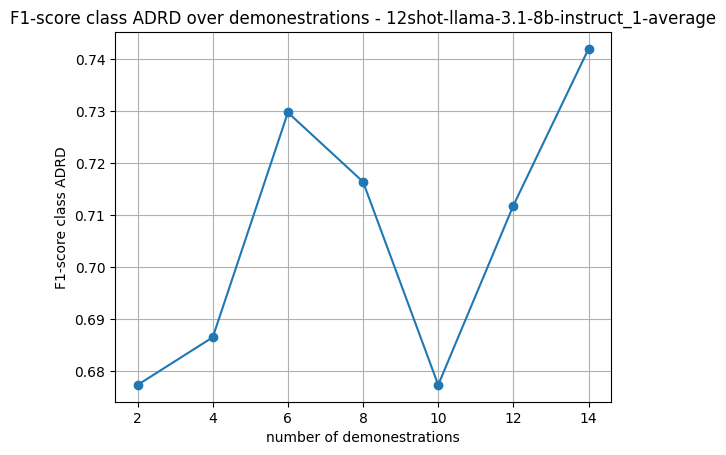

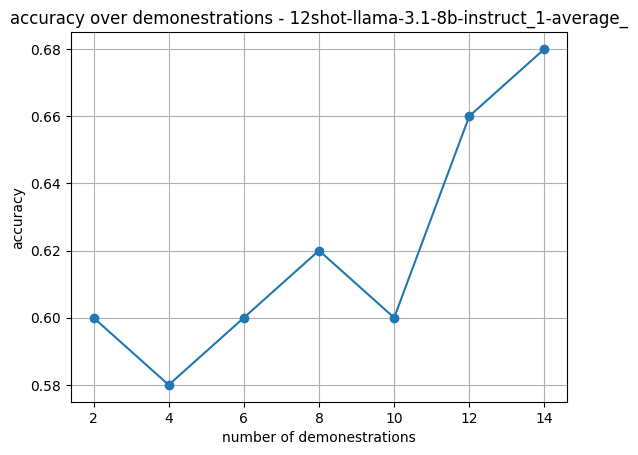

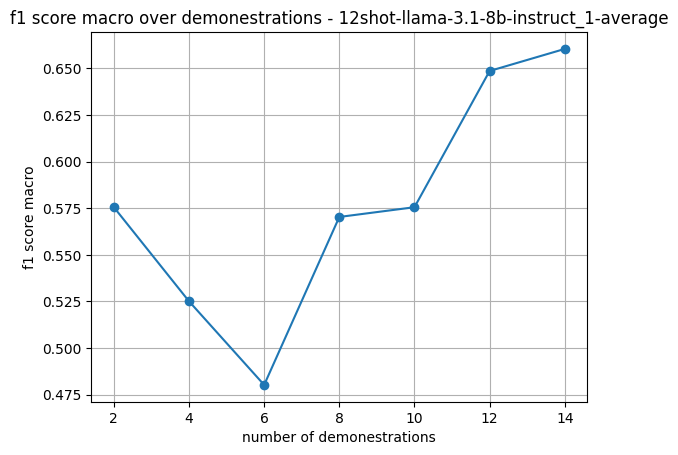

F1 score ADRD:
[np.float64(0.6774193548387096), np.float64(0.6865671641791045), np.float64(0.7297297297297297), np.float64(0.7164179104477612), np.float64(0.6774193548387096), np.float64(0.711864406779661), np.float64(0.7419354838709677)]
Accuracy of model:
[np.float64(0.6), np.float64(0.58), np.float64(0.6), np.float64(0.62), np.float64(0.6), np.float64(0.66), np.float64(0.68)]
F1 score macro
[np.float64(0.5755517826825127), np.float64(0.525101763907734), np.float64(0.4802494802494802), np.float64(0.5703301673450927), np.float64(0.5755517826825127), np.float64(0.6486151302190988), np.float64(0.6604414261460102)]


In [ ]:
train_df_with_emb = load_dataframe(train_embed_data_path)
valid_df_with_emb = load_dataframe(valid_embed_data_path)
test_df_with_emb = load_dataframe(test_embed_data_path)

CLASS_To_LABEL = {1 : "AD" , 0 : "Healthy"}
prompt_constructor = PromptConstructor()

client = OpenAI(api_key=openrouter_key, base_url=openrouter_base_url)

model_name = 'meta-llama/llama-3.1-8b-instruct'
OPENAI_MODEL_NAME = model_name
hf_model_name = 'unsloth/Meta-Llama-3.1-8B-Instruct'

max_number_of_demonestraions = 6
prompt_version = 'prompt_v2_reason'
distance_strategy = 'average'
has_sys_role = False
chat_compeletion = True


few_shots(client, 'valid', train_df_with_emb, valid_df_with_emb, 'text', 'emebdding_text', 'reasoning_label_gpt', reason=True, iterations=1,
              save_path=os.path.join(root_dir, 'few_shot/results/c'),
              results_path=os.path.join(root_dir, 'few_shot/results/reasoning_valid'))


few_shots(client, 'test', train_df_with_emb, test_df_with_emb, 'text+reason', 'emebdding_text_reason_gpt', 'reasoning_label_gpt',
          reason=True, iterations=1,
              save_path=os.path.join(root_dir, 'few_shot/results/reasoning'),
              results_path=os.path.join(root_dir, 'few_shot/results/reasoning'))

### ***With Llama 8 Reasoning***

<ipython-input-51-438834875>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 6777.03it/s]


meta-llama/llama-3.1-8b-instruct 0-shot average :
Accuracy (including -1 class): 0.6600
Class healthy - Precision: 0.5652, Recall: 0.6500, F1 Score: 0.6047
Class ADRD - Precision: 0.7407, Recall: 0.6667, F1 Score: 0.7018
Macro Precision : 0.6530
Macro Recall : 0.6583
Macro F1 Score : 0.6532
Results for approach 'llama-3.1-8b-instruct_1_prompt_v2_reason_0_shots_emb-text_reasoning_label_llama8' have been saved to /content/drive/MyDrive/speechCare/few_shot/results/reasoning_valid/results_llama-3.1-8b-instruct_1_test.csv.
mean time consumption is: 1.9296


<ipython-input-51-438834875>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


...

meta-llama/llama-3.1-8b-instruct 5-shot average :
Accuracy (including -1 class): 0.6000
Class healthy - Precision: 0.3043, Recall: 0.6364, F1 Score: 0.4118
Class ADRD - Precision: 0.8519, Recall: 0.5897, F1 Score: 0.6970
Macro Precision : 0.5781
Macro Recall : 0.6131
Macro F1 Score : 0.5544
Results for approach 'llama-3.1-8b-instruct_1_prompt_v2_reason_0_shots_emb-text_reasoning_label_llama8' have been saved to /content/drive/MyDrive/speechCare/few_shot/results/reasoning_valid/results_llama-3.1-8b-instruct_1_test.csv.
mean time consumption is: 1.8131


<ipython-input-51-438834875>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 6553.19it/s]


We find an error : the participant exhibits significant difficulty with memory, attention, and language, as evident from the numerous questions ("what do you call that?", "what is that?", "i don't know", "what's happening to the water?", etc.) and the struggles to recall the names of everyday objects ("cocoa", "coco", "cook", etc.). the participant's inability to maintain a logical sequence of thoughts and the expression of confusion and disorientation ("i don't know what's going on", "i don't know what that is") are common indicators of alzheimer's disease.
We find an error : " the participant's response is a coherent and descriptive narrative about a family scene, indicating normal cognitive function and ability to follow a sequence of events. there is no indication of confusion, disorientation, or memory loss, which are common symptoms of alzheimer's disease."
meta-llama/llama-3.1-8b-instruct 6-shot average :
Accuracy (including -1 class): 0.6400
Class healthy - Precision: 0.3478, R

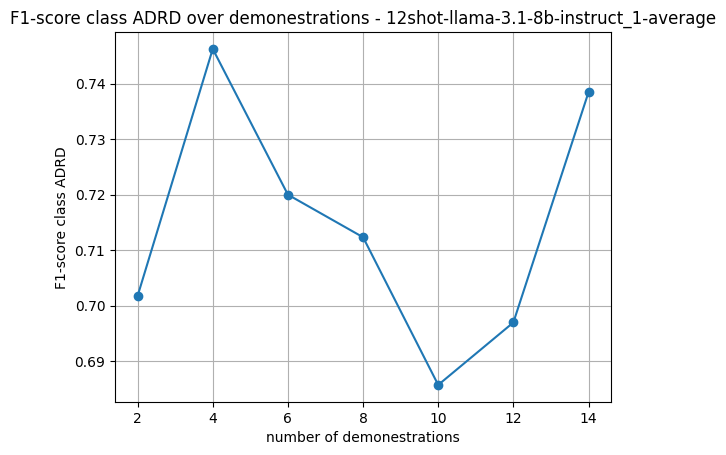

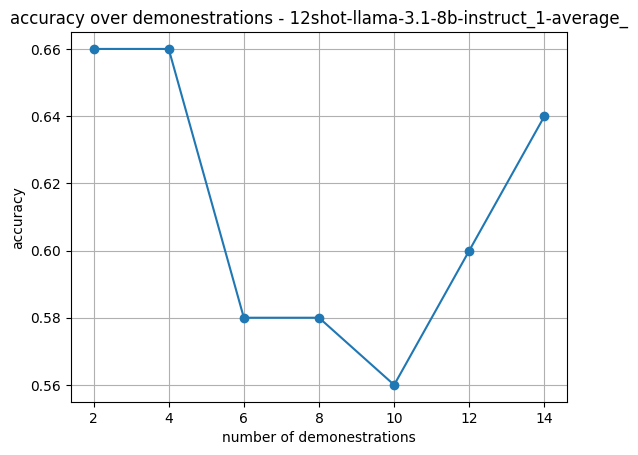

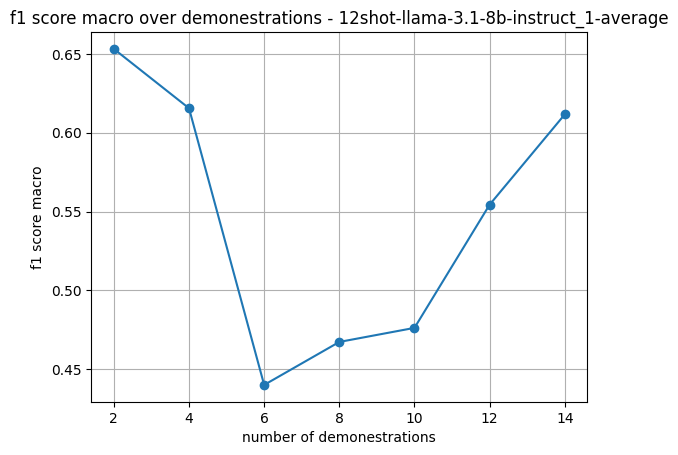

F1 score ADRD:
[np.float64(0.7017543859649122), np.float64(0.746268656716418), np.float64(0.72), np.float64(0.7123287671232876), np.float64(0.6857142857142857), np.float64(0.696969696969697), np.float64(0.7384615384615385)]
Accuracy of model:
[np.float64(0.66), np.float64(0.66), np.float64(0.58), np.float64(0.58), np.float64(0.56), np.float64(0.6), np.float64(0.64)]
F1 score macro
[np.float64(0.6532027743778049), np.float64(0.6155585707824514), np.float64(0.44), np.float64(0.4672754946727549), np.float64(0.47619047619047616), np.float64(0.554367201426025), np.float64(0.6116550116550117)]


In [ ]:
train_df_with_emb = load_dataframe(train_embed_data_path)
test_df_with_emb = load_dataframe(test_embed_data_path)
valid_df_with_emb = load_dataframe(valid_embed_data_path)

CLASS_To_LABEL = {1 : "AD" , 0 : "Healthy"}
prompt_constructor = PromptConstructor()

client = OpenAI(api_key=openrouter_key, base_url=openrouter_base_url)

model_name = 'meta-llama/llama-3.1-8b-instruct'
OPENAI_MODEL_NAME = model_name
hf_model_name = 'unsloth/Meta-Llama-3.1-8B-Instruct'

max_number_of_demonestraions = 6
prompt_version = 'prompt_v2_reason'
distance_strategy = 'average'
has_sys_role = False
chat_compeletion = True

few_shots(client, 'test', train_df_with_emb, test_df_with_emb, 'text', 'emebdding_text', 'reasoning_label_llama8',
          reason=True, iterations=1,
              save_path=os.path.join(root_dir, 'few_shot/results/reasoning'),
              results_path=os.path.join(root_dir, 'few_shot/results/reasoning'))

few_shots(client, 'valid', train_df_with_emb, valid_df_with_emb, 'text', 'emebdding_text', 'reasoning_label_llama8',
          reason=True, iterations=1,
              save_path=os.path.join(root_dir, 'few_shot/results/reasoning_valid'),
              results_path=os.path.join(root_dir, 'few_shot/results/reasoning_valid'))



### ***With Llama 405 Reasoning***

<ipython-input-56-2166512439>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 8807.86it/s]


meta-llama/llama-3.1-8b-instruct 1-shot average :
Accuracy (including -1 class): 0.6400
Class healthy - Precision: 0.2609, Recall: 0.8571, F1 Score: 0.4000
Class ADRD - Precision: 0.9630, Recall: 0.6047, F1 Score: 0.7429
Macro Precision : 0.6119
Macro Recall : 0.7309
Macro F1 Score : 0.5714
Results for approach 'llama-3.1-8b-instruct_1_prompt_v2_reason_0_shots_emb-text_reasoning_label_405' have been saved to /content/drive/MyDrive/speechCare/few_shot/results/reasoning_valid/results_llama-3.1-8b-instruct_1_test.csv.
mean time consumption is: 1.5126


<ipython-input-56-2166512439>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


...

meta-llama/llama-3.1-8b-instruct 5-shot average :
Accuracy (including -1 class): 0.6200
Class healthy - Precision: 0.3478, Recall: 0.6667, F1 Score: 0.4571
Class ADRD - Precision: 0.8519, Recall: 0.6053, F1 Score: 0.7077
Macro Precision : 0.5998
Macro Recall : 0.6360
Macro F1 Score : 0.5824
Results for approach 'llama-3.1-8b-instruct_1_prompt_v2_reason_0_shots_emb-text_reasoning_label_405' have been saved to /content/drive/MyDrive/speechCare/few_shot/results/reasoning_valid/results_llama-3.1-8b-instruct_1_test.csv.
mean time consumption is: 2.7246


<ipython-input-56-2166512439>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 7823.44it/s]

meta-llama/llama-3.1-8b-instruct 6-shot average :
Accuracy (including -1 class): 0.6800
Class healthy - Precision: 0.3913, Recall: 0.8182, F1 Score: 0.5294
Class ADRD - Precision: 0.9259, Recall: 0.6410, F1 Score: 0.7576
Macro Precision : 0.6586
Macro Recall : 0.7296
Macro F1 Score : 0.6435
Results for approach 'llama-3.1-8b-instruct_1_prompt_v2_reason_0_shots_emb-text_reasoning_label_405' have been saved to /content/drive/MyDrive/speechCare/few_shot/results/reasoning_valid/results_llama-3.1-8b-instruct_1_test.csv.
mean time consumption is: 2.8288


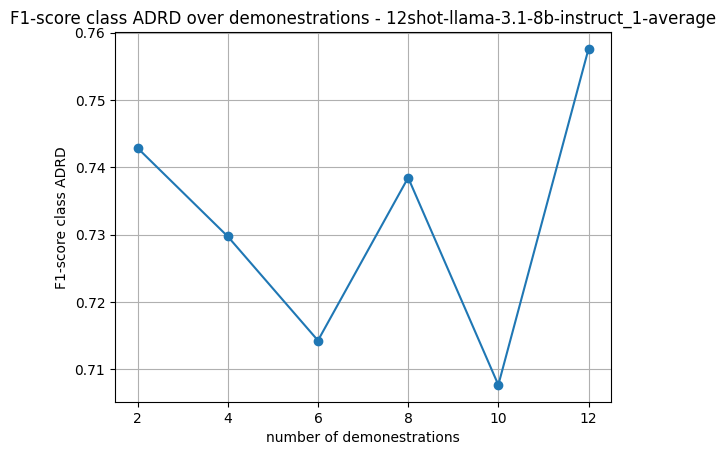

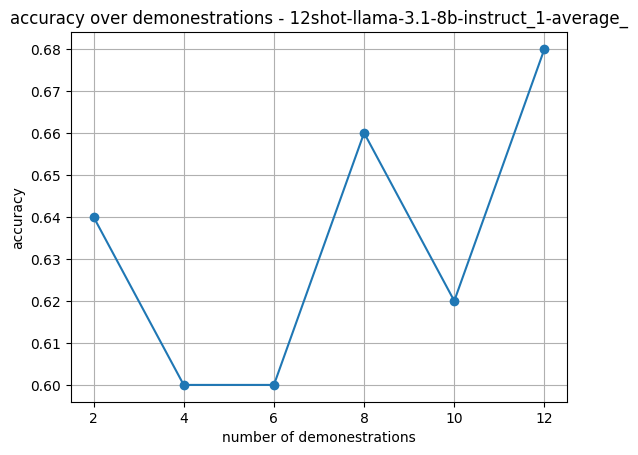

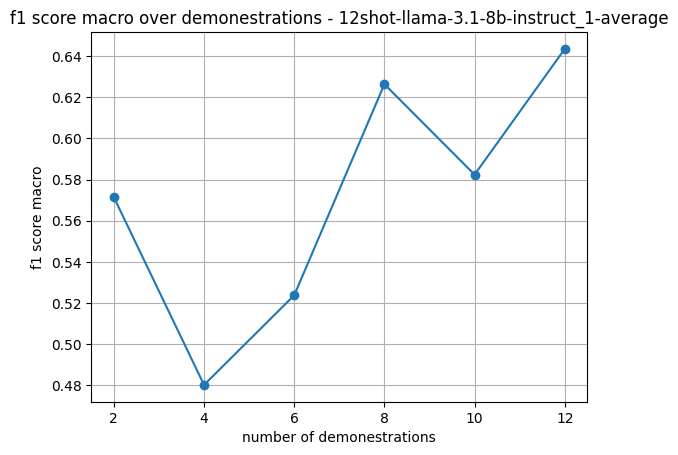

F1 score ADRD:
[np.float64(0.7428571428571429), np.float64(0.7297297297297297), np.float64(0.7142857142857143), np.float64(0.7384615384615385), np.float64(0.7076923076923077), np.float64(0.7575757575757576)]
Accuracy of model:
[np.float64(0.64), np.float64(0.6), np.float64(0.6), np.float64(0.66), np.float64(0.62), np.float64(0.68)]
F1 score macro
[np.float64(0.5714285714285714), np.float64(0.4802494802494802), np.float64(0.5238095238095238), np.float64(0.6263736263736264), np.float64(0.5824175824175825), np.float64(0.64349376114082)]


In [ ]:
train_df_with_emb = load_dataframe(train_embed_data_path)
# test_df_with_emb = load_dataframe(test_embed_data_path)
valid_df_with_emb = load_dataframe(valid_embed_data_path)

CLASS_To_LABEL = {1 : "AD" , 0 : "Healthy"}
prompt_constructor = PromptConstructor()

client = OpenAI(api_key=openrouter_key, base_url=openrouter_base_url)

model_name = 'meta-llama/llama-3.1-8b-instruct'
OPENAI_MODEL_NAME = model_name
hf_model_name = 'unsloth/Meta-Llama-3.1-8B-Instruct'

max_number_of_demonestraions = 6
prompt_version = 'prompt_v2_reason'
distance_strategy = 'average'
has_sys_role = False
chat_compeletion = True

few_shots(client, 'valid', train_df_with_emb, valid_df_with_emb, 'text', 'emebdding_text', 'reasoning_label_405',
          reason=True, iterations=1,
              save_path=os.path.join(root_dir, 'few_shot/results/reasoning_valid'),
              results_path=os.path.join(root_dir, 'few_shot/results/reasoning_valid'))



<ipython-input-24-3956fefde7ae>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


  0%|          | 0/71 [00:00<?, ?it/s]

100%|██████████| 71/71 [00:00<00:00, 13027.50it/s]


meta-llama/llama-3.1-8b-instruct 1-shot average :
Accuracy (including -1 class): 0.6338
Class healthy - Precision: 0.5556, Recall: 0.6667, F1 Score: 0.6061
Class ADRD - Precision: 0.7143, Recall: 0.6098, F1 Score: 0.6579
Macro Precision : 0.6349
Macro Recall : 0.6382
Macro F1 Score : 0.6320
Results for approach 'llama-3.1-8b-instruct_1_prompt_v2_reason_0_shots_emb-reason_reasoning_label_405' have been saved to /content/drive/MyDrive/speechCare/few_shot/results/reasoning/results_llama-3.1-8b-instruct_1_test.csv.
mean time consumption is: 1.9883


<ipython-input-24-3956fefde7ae>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


...

meta-llama/llama-3.1-8b-instruct 5-shot average :
Accuracy (including -1 class): 0.7183
Class healthy - Precision: 0.6667, Recall: 0.7500, F1 Score: 0.7059
Class ADRD - Precision: 0.7714, Recall: 0.6923, F1 Score: 0.7297
Macro Precision : 0.7190
Macro Recall : 0.7212
Macro F1 Score : 0.7178
Results for approach 'llama-3.1-8b-instruct_1_prompt_v2_reason_0_shots_emb-reason_reasoning_label_405' have been saved to /content/drive/MyDrive/speechCare/few_shot/results/reasoning/results_llama-3.1-8b-instruct_1_test.csv.
mean time consumption is: 2.3433


<ipython-input-24-3956fefde7ae>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


  0%|          | 0/71 [00:00<?, ?it/s]

100%|██████████| 71/71 [00:00<00:00, 12386.47it/s]

We find an error : The participant's transcript is categorized as 'AD' due to the presence of several indicators, including: (1) difficulty with coherence and logical flow, 2) difficulty with word retrieval and naming (e.g., 'Yeah girl healthy'), (3) repetition of ideas (e.g., 'he's going to fall' and 'he might fall senate'), and (4) apparent confusion and disorganization in the narrative. These linguistic features are commonly associated with the cognitive and communicative impairments characteristic of Alzheimer's disease.
meta-llama/llama-3.1-8b-instruct 6-shot average :
Accuracy (including -1 class): 0.6620
Class healthy - Precision: 0.6944, Recall: 0.6757, F1 Score: 0.6849
Class ADRD - Precision: 0.6286, Recall: 0.6667, F1 Score: 0.6471
Macro Precision : 0.6615
Macro Recall : 0.6712
Macro F1 Score : 0.6660
Results for approach 'llama-3.1-8b-instruct_1_prompt_v2_reason_0_shots_emb-reason_reasoning_label_405' have been saved to /content/drive/MyDrive/speechCare/few_shot/results/reas

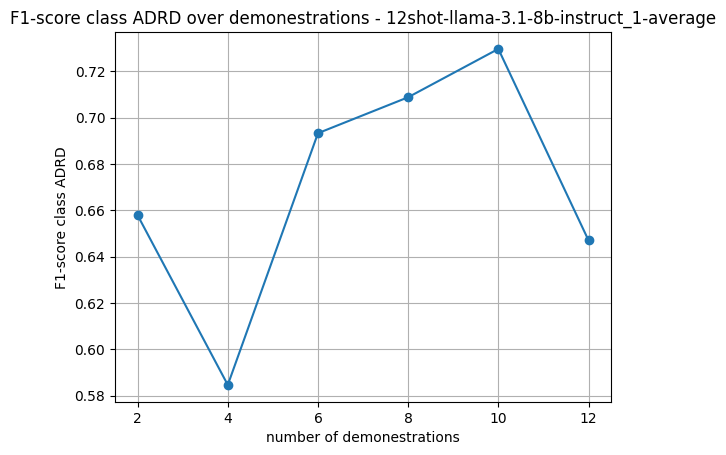

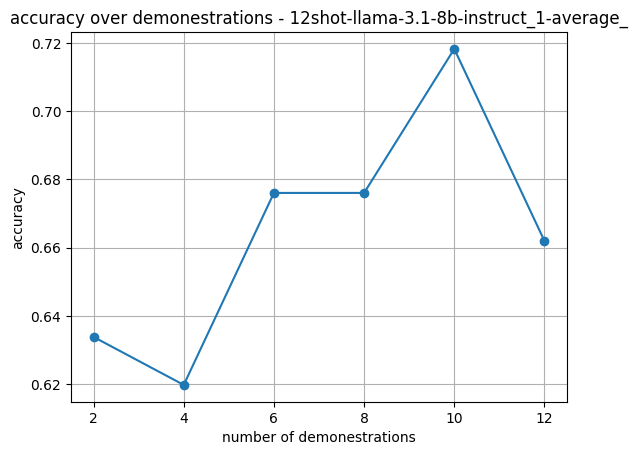

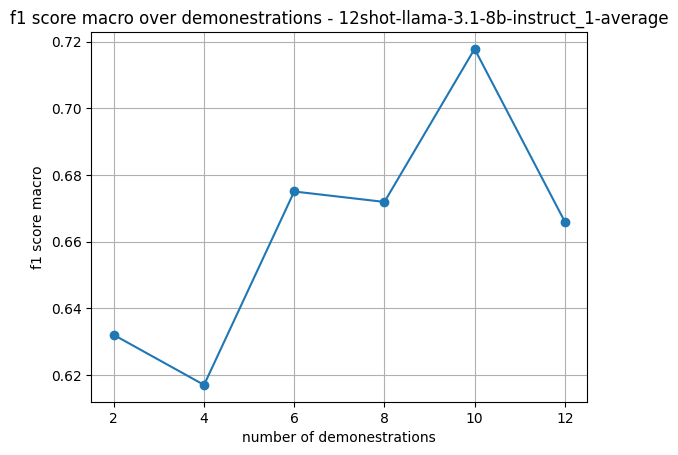

F1 score ADRD:
[np.float64(0.6578947368421053), np.float64(0.5846153846153846), np.float64(0.6933333333333334), np.float64(0.7088607594936709), np.float64(0.7297297297297297), np.float64(0.6470588235294118)]
Accuracy of model:
[np.float64(0.6338028169014085), np.float64(0.6197183098591549), np.float64(0.676056338028169), np.float64(0.676056338028169), np.float64(0.7183098591549296), np.float64(0.6619718309859155)]
F1 score macro
[np.float64(0.6319776714513556), np.float64(0.616983016983017), np.float64(0.6750248756218906), np.float64(0.6718906972071529), np.float64(0.7178060413354531), np.float64(0.6659951651893634)]


In [ ]:
train_df_with_emb = load_dataframe(train_embed_data_path)
test_df_with_emb = load_dataframe(test_embed_data_path)

CLASS_To_LABEL = {1 : "AD" , 0 : "Healthy"}
prompt_constructor = PromptConstructor()

client = OpenAI(api_key=openrouter_key, base_url=openrouter_base_url)

model_name = 'meta-llama/llama-3.1-8b-instruct'
OPENAI_MODEL_NAME = model_name
hf_model_name = 'unsloth/Meta-Llama-3.1-8B-Instruct'

max_number_of_demonestraions = 6
prompt_version = 'prompt_v2_reason'
distance_strategy = 'average'
has_sys_role = False
chat_compeletion = True

few_shots(client, 'test', train_df_with_emb, test_df_with_emb, 'reason', 'emebdding_reasoning_label_405', 'reasoning_label_405',
          reason=True, iterations=1,
              save_path=os.path.join(root_dir, 'few_shot/results/reasoning'),
              results_path=os.path.join(root_dir, 'few_shot/results/reasoning'))



## ***(2)	Self-Consistency with Teacher-Generated Reasoning***

In [ ]:
train_df_with_emb = load_dataframe(train_embed_data_path)
test_df_with_emb = load_dataframe(test_embed_data_path)
valid_df_with_emb = load_dataframe(valid_embed_data_path)

CLASS_To_LABEL = {1 : "AD" , 0 : "Healthy"}
prompt_constructor = PromptConstructor()

client = OpenAI(api_key=openrouter_key, base_url=openrouter_base_url)

model_name = 'meta-llama/llama-3.1-8b-instruct'
OPENAI_MODEL_NAME = model_name
hf_model_name = 'unsloth/Meta-Llama-3.1-8B-Instruct'

max_number_of_demonestraions = 6
prompt_version = 'prompt_v2_reason'
distance_strategy = 'average'
has_sys_role = False
chat_compeletion = True

In [ ]:
self_consistency_few_shot_zero(client, 'test', train_df_with_emb, test_df_with_emb,
                          'text', 'emebdding_text', 'reasoning_label_gpt',
                          reason=True, iterations=1,
                          save_path=os.path.join(root_dir, 'few_shot/results/reasoning_self_consistency_temp04'),
                          results_path=os.path.join(root_dir, 'few_shot/results/reasoning_self_consistency_temp04'))

self_consistency_few_shot_zero(client, 'valid', train_df_with_emb, valid_df_with_emb,
                          'text', 'emebdding_text', 'reasoning_label_405',
                          reason=True, iterations=1, temperature=0.4,
                          save_path=os.path.join(root_dir, 'few_shot/results/reasoning_self_consistency_temp04_valid'),
                          results_path=os.path.join(root_dir, 'few_shot/results/reasoning_self_consistency_temp04_valid'))



## ***(3)	Tree-of-Thought (ToT) Reasoning***

### ***ToT 1 - Unspecified experts***

<ipython-input-42-4201589497>:19: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 7523.42it/s]


We find an error :  [
  "step 1: i notice that the speaker demonstrates a moderate level of lexical diversity (words like 'stepladder', 'spilled', 'terribly') and some complex syntactic structures, including embedded clauses ('which is ready to fall'). however, there are some disfluencies ('uh') and repetitive word usage ('cookie jar', 'cookies').",
  "step 2: semantic coherence is generally good, but there are some minor issues with maintaining thematic focus. the speaker jumps between ideas, but they are still connected logically. i continue with my analysis and see no reason to believe this indicates ad."],
"neurocognitive researcher studying everyday speech" :  [
  "step 1: i observe that the discourse remains organized around a clear central event (cookie theft scene) and progresses logically, despite minor interruptions. the participant maintains the storyline and elaborates on multiple visual elements.",
  "step 2: pragmatic language use seems generally appropriate; references t

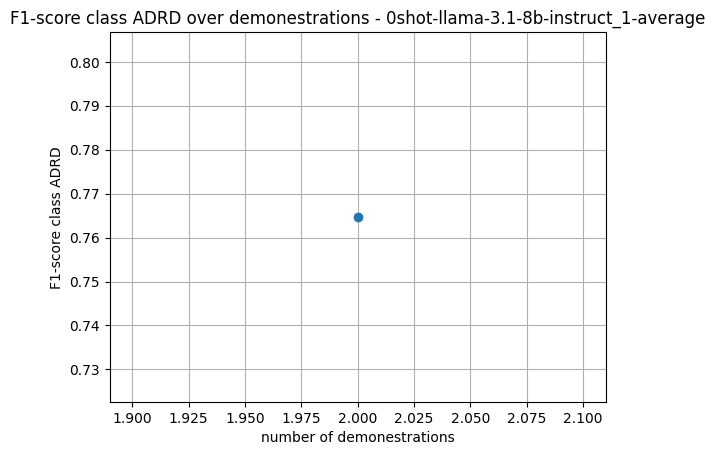

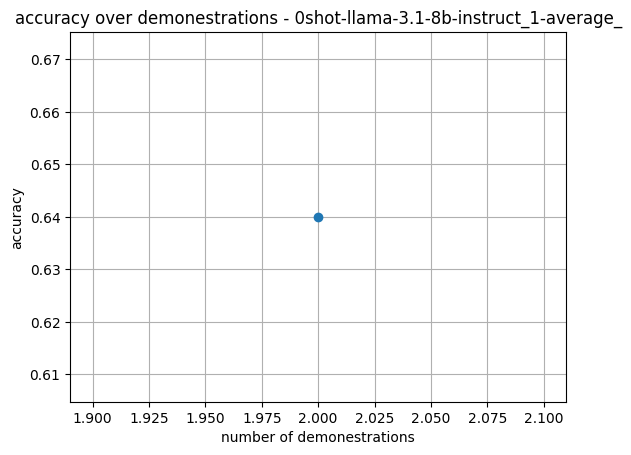

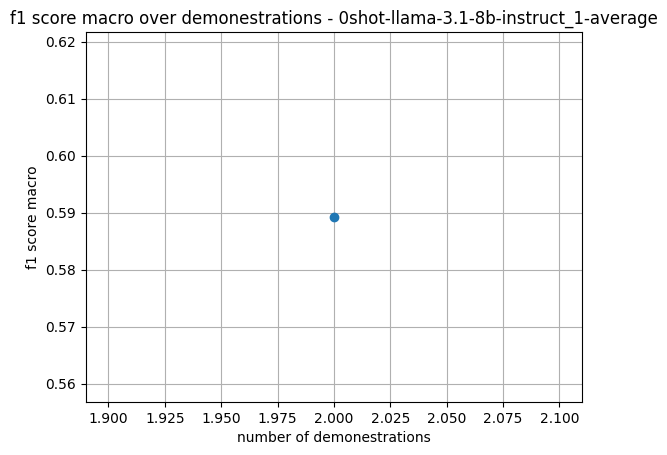

F1 score ADRD:
[np.float64(0.7647058823529411)]
Accuracy of model:
[np.float64(0.64)]
F1 score macro
[np.float64(0.5892494929006085)]


In [ ]:
train_df_with_emb = load_dataframe(train_embed_data_path)
# test_df_with_emb = load_dataframe(test_embed_data_path)
valid_df_with_emb = load_dataframe(valid_embed_data_path)

CLASS_To_LABEL = {1 : "AD" , 0 : "Healthy"}
prompt_constructor = PromptConstructor()

client = OpenAI(api_key=openrouter_key, base_url=openrouter_base_url)

model_name = 'meta-llama/llama-3.1-8b-instruct'
OPENAI_MODEL_NAME = model_name
hf_model_name = 'unsloth/Meta-Llama-3.1-8B-Instruct'

max_number_of_demonestraions = 0
prompt_version = 'tot_3exp_1'
distance_strategy = 'average'
has_sys_role = False
chat_compeletion = True

tree_of_thoughts(client, 'test', train_df_with_emb, test_df_with_emb,
                          'text', 'emebdding_text', 'reasoning_label_gpt',
                          reason=True, iterations=1, include_demonstration=True,
                          save_path=os.path.join(root_dir, 'few_shot/results/ToT_exp3'),
                          results_path=os.path.join(root_dir, 'few_shot/results/ToT_exp3'))

tree_of_thoughts(client, 'valid', train_df_with_emb, valid_df_with_emb,
                          'text', 'emebdding_text', 'reasoning_label_gpt',
                          reason=True, iterations=1, include_demonstration=True,
                          save_path=os.path.join(root_dir, 'few_shot/results/valid_tot'),
                          results_path=os.path.join(root_dir, 'few_shot/results/valid_tot'))



### ***ToT 2 - Domain-specific experts***

In [ ]:
train_df_with_emb = load_dataframe(train_embed_data_path)
# test_df_with_emb = load_dataframe(test_embed_data_path)
valid_df_with_emb = load_dataframe(valid_embed_data_path)

CLASS_To_LABEL = {1 : "AD" , 0 : "Healthy"}
prompt_constructor = PromptConstructor()

client = OpenAI(api_key=openrouter_key, base_url=openrouter_base_url)

model_name = 'meta-llama/llama-3.1-8b-instruct'
OPENAI_MODEL_NAME = model_name
hf_model_name = 'unsloth/Meta-Llama-3.1-8B-Instruct'

max_number_of_demonestraions = 0
prompt_version = 'tot_3exp_2'
distance_strategy = 'average'
has_sys_role = False
chat_compeletion = True

tree_of_thoughts(client, 'test', train_df_with_emb, test_df_with_emb,
                          'text', 'emebdding_text', 'reasoning_label_gpt',
                          reason=True, iterations=1, include_demonstration=True,
                          save_path=os.path.join(root_dir, 'few_shot/results/ToT_exp3'),
                          results_path=os.path.join(root_dir, 'few_shot/results/ToT_exp3'))

tree_of_thoughts(client, 'valid', train_df_with_emb, valid_df_with_emb,
                          'text', 'emebdding_text', 'reasoning_label_gpt',
                          reason=True, iterations=1, include_demonstration=True,
                          save_path=os.path.join(root_dir, 'few_shot/results/valid_tot'),
                          results_path=os.path.join(root_dir, 'few_shot/results/valid_tot'))



<ipython-input-39-438834875>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 9458.13it/s]


meta-llama/llama-3.3-70b-instruct 0-shot average :
Accuracy (including -1 class): 0.6200
Class healthy - Precision: 0.3478, Recall: 0.6667, F1 Score: 0.4571
Class ADRD - Precision: 0.8519, Recall: 0.6053, F1 Score: 0.7077
Macro Precision : 0.5998
Macro Recall : 0.6360
Macro F1 Score : 0.5824
Results for approach 'llama-3.3-70b-instruct_1_prompt_v2_reason_0_shots_emb-text_reasoning_label_405' have been saved to /content/drive/MyDrive/speechCare/few_shot/results/reasoning/results_llama-3.3-70b-instruct_1_test.csv.
mean time consumption is: 2.6724


<ipython-input-39-438834875>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


...

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 6708.95it/s]


meta-llama/llama-3.3-70b-instruct 4-shot average :
Accuracy (including -1 class): 0.6800
Class healthy - Precision: 0.3478, Recall: 0.8889, F1 Score: 0.5000
Class ADRD - Precision: 0.9630, Recall: 0.6341, F1 Score: 0.7647
Macro Precision : 0.6554
Macro Recall : 0.7615
Macro F1 Score : 0.6324
Results for approach 'llama-3.3-70b-instruct_1_prompt_v2_reason_0_shots_emb-text_reasoning_label_405' have been saved to /content/drive/MyDrive/speechCare/few_shot/results/reasoning/results_llama-3.3-70b-instruct_1_test.csv.
mean time consumption is: 5.1746


<ipython-input-39-438834875>:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for index_test, (idx, row_test) in enumerate(tqdm_notebook(test_data.iterrows(), total=len(test_data))):


  0%|          | 0/50 [00:00<?, ?it/s]